## Estudiando y repasando 

In [20]:
import torch 
import matplotlib.pyplot as plt


In [21]:
#creando una red neuronal

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.01

x = torch.arange(start=start, end=end, step=step).unsqueeze(dim=1)
y = weight * x + bias

len(x), len(y)

(100, 100)

In [22]:
# split into training and testing 

train_split = int(0.8 * len(x))

X_train, y_train = x[:train_split], y[:train_split]
X_test, y_test = x[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(80, 80, 20, 20)

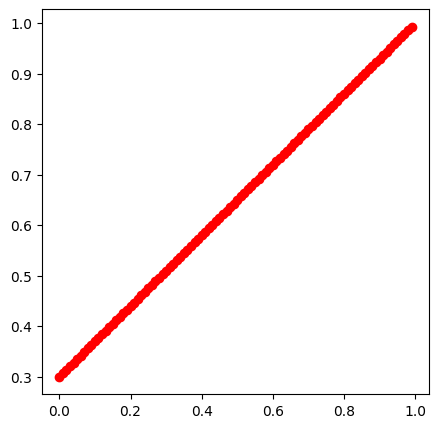

In [23]:
plt.figure(figsize=(5,5))
plt.scatter(x=x,
            y=y,
            c='r')       

In [24]:
from torch import nn

class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(1 ,requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x):
        return self.weight * x + self.bias


In [25]:
model = LinearRegression()

model.state_dict(), model.parameters()

(OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))]),
 <generator object Module.parameters at 0x13a50c9e0>)

In [26]:
# funcion de perdida 

fn = nn.L1Loss()

# optimizador
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)



In [32]:
## training 
torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
    model.train()

    y_pred = model(X_train)

    loss = fn(y_pred, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    print(f"epoch {epoch}: loss: {loss}")
    if epoch % 10 == 0 or epoch == 99:
        print(f"Parameters: {model.state_dict()}")
    

    



epoch 0: loss: 0.0054215178824961185
Parameters: OrderedDict({'weight': tensor([0.6983]), 'bias': tensor([0.3068])})
epoch 1: loss: 0.006138724274933338
epoch 2: loss: 0.0054215178824961185
epoch 3: loss: 0.006138724274933338
epoch 4: loss: 0.0054215178824961185
epoch 5: loss: 0.006138724274933338
epoch 6: loss: 0.0054215178824961185
epoch 7: loss: 0.006138724274933338
epoch 8: loss: 0.0054215178824961185
epoch 9: loss: 0.006138724274933338
epoch 10: loss: 0.0054215178824961185
Parameters: OrderedDict({'weight': tensor([0.6983]), 'bias': tensor([0.3068])})
epoch 11: loss: 0.006138724274933338
epoch 12: loss: 0.0054215178824961185
epoch 13: loss: 0.006138724274933338
epoch 14: loss: 0.0054215178824961185
epoch 15: loss: 0.006138724274933338
epoch 16: loss: 0.0054215178824961185
epoch 17: loss: 0.006138724274933338
epoch 18: loss: 0.0054215178824961185
epoch 19: loss: 0.006138724274933338
epoch 20: loss: 0.0054215178824961185
Parameters: OrderedDict({'weight': tensor([0.6983]), 'bias': t

In [33]:
model.eval()

with torch.inference_mode():
    test_pred = model(X_test)

model.state_dict()

OrderedDict([('weight', tensor([0.6944])), ('bias', tensor([0.2968]))])